In [18]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.api import VAR

from load import load_symbol_folder
from preprocess import build_merged
from cointegration import compute_mean_reverting_spread

In [19]:
start_date = "2024-07-22"
end_date = "2024-10-15"
cxw_data = load_symbol_folder("CXW_data", start_date=start_date, end_date=end_date)
geo_data = load_symbol_folder("GEO_data", start_date=start_date, end_date=end_date)

In [20]:
pdf = build_merged(geo_data, cxw_data)
pdf.head()

,mid_geo,mid_cxw
ts_event,,
2024-07-22 10:30:00,16.235,14.505
2024-07-22 10:31:00,16.250,14.505
2024-07-22 10:32:00,16.255,14.505
2024-07-22 10:33:00,16.260,14.520
2024-07-22 10:34:00,16.255,14.535


In [21]:
split_date = "2024-09-15"

train = pdf.loc[pdf.index < split_date].copy()
test = pdf.loc[pdf.index >= split_date].copy()

print("Train period:", train.index.min(), "→", train.index.max())
print("Test period :", test.index.min(), "→", test.index.max())
print("Train size:", len(train))
print("Test size :", len(test))

Train period: 2024-07-22 10:30:00 → 2024-09-13 14:59:00
Test period : 2024-09-16 10:30:00 → 2024-10-15 14:59:00
Train size: 10513
Test size : 5920


In [22]:
alpha, spread, kappa, theta, eigvals = compute_mean_reverting_spread(train, cols=("mid_geo", "mid_cxw"))

VAR(1) on ΔS_t results
A (intercept): [-0.00035143 -0.00012997]
B (lag-1 matrix):
 [[-0.08499795  0.08863903]
 [ 0.042407   -0.04107421]]

Derived kappa = (I - B)/dt:
 [[ 1.08499795 -0.08863903]
 [-0.042407    1.04107421]]
Derived theta = kappa^{-1} A dt: [-0.00033522 -0.0001385 ]

Eigenvalues of kappa: [1.12816088 0.99791129]
Chosen eigenvalue (fastest MR): 1.1281608760253825

Best linear combination (up to scale/sign):
  spread =  1.000000 * mid_geo  + -0.486952 * mid_cxw

Same combo normalized to second asset coefficient = 1:
  spread = -2.053592 * mid_geo  + 1.000000 * mid_cxw


c:\Users\Laurent Liao\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [23]:
def make_spread_from_alpha(df, alpha, cols=("mid_geo", "mid_cxw"), name="spread"):
    S = df[list(cols)].dropna()
    s = pd.Series(S.values @ alpha, index=S.index, name=name)
    return s.sort_index()

def clip_and_zscore_train_test(spread_train, spread_test, clip_q=(0.001, 0.999)):
    lo, hi = spread_train.quantile(list(clip_q))
    train_clip = spread_train.clip(lo, hi)
    mu = train_clip.mean()
    sd = train_clip.std(ddof=0) if train_clip.std(ddof=0) > 0 else 1.0

    train_z = (train_clip - mu) / sd

    test_clip = spread_test.clip(lo, hi)
    test_z = (test_clip - mu) / sd

    meta = {"clip_lo": lo, "clip_hi": hi, "mu": mu, "sd": sd}
    return train_z, test_z, meta


spread_train = make_spread_from_alpha(train, alpha, cols=("mid_cxw","mid_geo"), name="spread")
spread_test  = make_spread_from_alpha(test,  alpha, cols=("mid_cxw","mid_geo"), name="spread")

spread_train_z, spread_test_z, zmeta = clip_and_zscore_train_test(spread_train, spread_test)

spread_full_z = pd.concat([spread_train_z, spread_test_z]).sort_index()

train_feat_hid = pd.DataFrame({"spread_z": spread_train_z}).dropna().sort_index()
test_feat_hid  = pd.DataFrame({"spread_z": spread_test_z}).dropna().sort_index()

In [34]:
import gymnasium as gym
from gymnasium import spaces


class SpreadTradingEnvWindow(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        feat_df,
        W=10,
        episode_len=2000,
        Imax=10.0,
        trading_costs=0.05,
        quad_inventory_penalty=0.001,
        terminal_inventory_penalty=0.01,
        seed=None,
    ):
        super().__init__()
        self.df = feat_df
        self.W = int(W)
        self.Imax = float(Imax)
        self.trading_costs = float(trading_costs)
        self.quad_inventory_penalty = float(quad_inventory_penalty)
        self.terminal_inventory_penalty = float(terminal_inventory_penalty)

        self.episode_len = int(min(episode_len, len(self.df) - (self.W + 2)))
        self._rng = np.random.default_rng(seed)

        self.obs_dim = (self.W + 1) + 1
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-self.Imax, high=self.Imax, shape=(1,), dtype=np.float32
        )

        self.start = self.W
        self.t = self.W
        self.steps = 0
        self.I = 0.0

    def _get_obs(self):
        s_window = (
            self.df["spread_z"]
            .iloc[self.t - self.W : self.t + 1]
            .to_numpy(dtype=np.float32)
        )
        return np.concatenate([s_window, np.array([self.I], dtype=np.float32)])

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)

        print(
            f"[ENV reset] start={self.start} t={self.t} episode_len={self.episode_len} I={self.I}"
        )
        max_start = len(self.df) - (self.W + 2) - self.episode_len
        self.start = int(
            self._rng.integers(self.W, max(self.W + 1, max_start + self.W))
        )
        self.t = self.start
        self.steps = 0
        self.I = 0.0
        return self._get_obs(), {}

    def step(self, action):
        I_next = float(np.clip(action[0], -self.Imax, self.Imax))

        s_t = float(self.df["spread_z"].iloc[self.t])
        s_next = float(self.df["spread_z"].iloc[self.t + 1])

        dS = s_next - s_t
        q = I_next - self.I

        reward = (
            I_next * dS
            - self.trading_costs * abs(q)
            - self.quad_inventory_penalty * (I_next**2)
        )

        self.I = I_next
        self.t += 1
        self.steps += 1

        terminated = False
        truncated = self.steps >= self.episode_len
        if truncated:
            reward -= self.terminal_inventory_penalty * abs(self.I)

        if self.steps % 25000 == 0:
            print(
                f"[ENV step] t={self.t} I={self.I:.3f} I_next={I_next:.3f} dS={dS:.4f} q={q:.3f} r={reward:.4f}"
            )
        obs = self._get_obs()
        info = {
            "inventory": self.I,
            "spread_z": s_next,
            "q": q,
            "dS": dS,
            "reward": reward,
        }
        return obs, reward, terminated, truncated, info


class SpreadTradingEnvWindowSequential(SpreadTradingEnvWindow):
    def reset(self, seed=None, options=None):
        self.start = self.W
        self.t = self.W
        self.steps = 0
        self.I = 0.0
        self.episode_len = len(self.df) - (self.W + 2)
        return self._get_obs(), {}

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GRUEncoder(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=10, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )

    def forward(self, x):
        # x: (B, T, 1)
        out, h = self.gru(x)
        # (num_layers, B, hidden_dim) -> (B, hidden_dim)
        return h[-1]


class Actor(nn.Module):
    def __init__(self, gru_hidden_dim, inv_dim=1, action_dim=1, Imax=10.0, mlp=(64, 64)):
        super().__init__()
        self.Imax = float(Imax)
        in_dim = gru_hidden_dim + inv_dim
        layers = []
        prev = in_dim
        for h in mlp:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers += [nn.Linear(prev, action_dim), nn.Tanh()]
        self.net = nn.Sequential(*layers)

    def forward(self, g, inv):
        x = torch.cat([g, inv], dim=-1)
        a = self.net(x) * self.Imax
        return a


class Critic(nn.Module):
    def __init__(self, gru_hidden_dim, inv_dim=1, action_dim=1, mlp=(64, 64)):
        super().__init__()
        in_dim = gru_hidden_dim + inv_dim + action_dim
        layers = []
        prev = in_dim
        for h in mlp:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, g, inv, a):
        x = torch.cat([g, inv, a], dim=-1)
        q = self.net(x)
        return q

In [36]:
from collections import deque
import random

class ReplayBuffer:
    def __init__(self, capacity=200_000):
        self.buf = deque(maxlen=int(capacity))

    def push(self, obs, act, rew, next_obs, done):
        self.buf.append((obs, act, rew, next_obs, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        obs, act, rew, next_obs, done = map(np.array, zip(*batch))
        return obs, act, rew, next_obs, done

    def __len__(self):
        return len(self.buf)

In [37]:
def soft_update(tgt, src, tau=0.005):
    for p_t, p in zip(tgt.parameters(), src.parameters()):
        p_t.data.mul_(1.0 - tau).add_(tau * p.data)


def to_torch(x):
    return torch.as_tensor(x, dtype=torch.float32, device=device)


def split_obs(obs, W):
    # obs: (B, W+2) = (S_window length W+1) + inventory
    s_win = obs[:, : W + 1]  # (B, W+1)
    inv = obs[:, W + 1 : W + 2]  # (B, 1)
    s_win = s_win.unsqueeze(-1)  # (B, W+1, 1)
    return s_win, inv


def train_hid_ddpg(
    env,
    W=10,
    hidden_dim=10,
    num_layers=1,
    Imax=10.0,
    total_steps=100_000,
    start_steps=5_000,
    batch_size=256,
    gamma=0.98,
    tau=0.005,
    lr=1e-3,
    noise_std=0.3,
    noise_decay=0.999,
    min_noise=0.05,
    buffer_size=200_000,
    seed=123,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    enc = GRUEncoder(input_dim=1, hidden_dim=hidden_dim, num_layers=num_layers).to(
        device
    )
    actor = Actor(gru_hidden_dim=hidden_dim, Imax=Imax).to(device)
    critic = Critic(gru_hidden_dim=hidden_dim).to(device)

    enc_tgt = GRUEncoder(input_dim=1, hidden_dim=hidden_dim, num_layers=num_layers).to(
        device
    )
    actor_tgt = Actor(gru_hidden_dim=hidden_dim, Imax=Imax).to(device)
    critic_tgt = Critic(gru_hidden_dim=hidden_dim).to(device)

    enc_tgt.load_state_dict(enc.state_dict())
    actor_tgt.load_state_dict(actor.state_dict())
    critic_tgt.load_state_dict(critic.state_dict())

    critic_opt = optim.Adam(list(enc.parameters()) + list(critic.parameters()), lr=lr)
    actor_opt = optim.Adam(list(enc.parameters()) + list(actor.parameters()), lr=lr)

    rb = ReplayBuffer(capacity=buffer_size)

    obs, _ = env.reset(seed=seed)
    eps = float(noise_std)

    for step in range(1, total_steps + 1):
        obs_b = torch.as_tensor(obs[None, :], dtype=torch.float32, device=device)
        s_win, inv = split_obs(obs_b, W)
        with torch.no_grad():
            g = enc(to_torch(s_win))
            a = actor(g, to_torch(inv)).cpu().numpy()[0]

        if step < start_steps:
            a = np.array([np.random.uniform(-Imax, Imax)], dtype=np.float32)
        else:
            a = a + np.random.normal(0.0, eps, size=a.shape).astype(np.float32)
            a = np.clip(a, -Imax, Imax)

        next_obs, r, term, trunc, info = env.step(a)
        done = term or trunc

        rb.push(
            obs.astype(np.float32),
            a.astype(np.float32),
            float(r),
            next_obs.astype(np.float32),
            float(done),
        )
        obs = next_obs

        if done:
            obs, _ = env.reset()

        if len(rb) >= batch_size and step >= start_steps:
            o, a_b, r_b, o2, d_b = rb.sample(batch_size)

            o = to_torch(o)
            a_b = to_torch(a_b)
            r_b = to_torch(r_b).unsqueeze(-1)
            o2 = to_torch(o2)
            d_b = to_torch(d_b).unsqueeze(-1)

            s1, inv1 = split_obs(o, W)
            s2, inv2 = split_obs(o2, W)

            g1 = enc(s1)
            q1 = critic(g1, inv1, a_b)

            with torch.no_grad():
                g2 = enc_tgt(s2)
                a2 = actor_tgt(g2, inv2)
                q2 = critic_tgt(g2, inv2, a2)
                y = r_b + gamma * (1.0 - d_b) * q2

            critic_loss = (q1 - y).pow(2).mean()
            critic_opt.zero_grad()
            critic_loss.backward()
            critic_opt.step()

            g1_for_actor = enc(s1).detach()
            a_pi = actor(g1_for_actor, inv1)
            actor_loss = -critic(g1_for_actor, inv1, a_pi).mean()

            actor_opt.zero_grad()
            actor_loss.backward()
            actor_opt.step()

            soft_update(enc_tgt, enc, tau=tau)
            soft_update(actor_tgt, actor, tau=tau)
            soft_update(critic_tgt, critic, tau=tau)

            eps = max(min_noise, eps * noise_decay)

        if step % 1000 == 0:
            print(
                f"[TRAIN] step={step} eps={eps:.4f} a={a[0]:.3f} obs_spread_last={obs[W]:.3f} inv={obs[W + 1]:.3f} rb={len(rb)}"
            )

    return enc, actor, critic

In [38]:
W = 10
Imax = 10.0
trading_costs=0.01
quad_inventory_penalty=0.001
terminal_inventory_penalty=0.01

train_env_hid = SpreadTradingEnvWindow(
    train_feat_hid,
    W=W,
    episode_len=2000,
    Imax=Imax,
    trading_costs=trading_costs,
    quad_inventory_penalty=quad_inventory_penalty,
    terminal_inventory_penalty=terminal_inventory_penalty,
    seed=123,
)

enc, actor, critic = train_hid_ddpg(
    train_env_hid,
    W=W,
    hidden_dim=10,
    num_layers=1,
    Imax=Imax,
    total_steps=100_000,
    gamma=0.98,
    tau=0.005,
    lr=1e-3,
    noise_std=0.5,
)

test_env_hid = SpreadTradingEnvWindowSequential(
    test_feat_hid,
    W=W,
    episode_len=len(test_feat_hid) - (W + 2),
    Imax=Imax,
    trading_costs=trading_costs,
    quad_inventory_penalty=quad_inventory_penalty,
    terminal_inventory_penalty=terminal_inventory_penalty,
)

obs, _ = test_env_hid.reset()
rewards, inventories, spreads, actions, ts = [], [], [], [], test_feat_hid.index

for _ in range(len(test_feat_hid) - (W + 2)):
    obs_b = torch.as_tensor(obs[None, :], dtype=torch.float32, device=device)
    s_win, inv = split_obs(obs_b, W)
    with torch.no_grad():
        g = enc(s_win)
        a = actor(g, inv).cpu().numpy()[0]
    obs, r, term, trunc, info = test_env_hid.step(a)

    rewards.append(r)
    inventories.append(info["inventory"])
    spreads.append(info["spread_z"])
    actions.append(info["q"])
    if term or trunc:
        break

cum_pnl_hid = np.cumsum(np.asarray(rewards, dtype=float))


[ENV reset] start=10 t=10 episode_len=2000 I=0.0
[TRAIN] step=1000 eps=0.5000 a=-4.102 obs_spread_last=0.638 inv=-4.102 rb=1000
[ENV reset] start=141 t=2141 episode_len=2000 I=-8.042741775512695
[TRAIN] step=2000 eps=0.5000 a=-8.043 obs_spread_last=-0.756 inv=0.000 rb=2000
[TRAIN] step=3000 eps=0.5000 a=-1.096 obs_spread_last=0.406 inv=-1.096 rb=3000
[ENV reset] start=5810 t=7810 episode_len=2000 I=2.457571506500244
[TRAIN] step=4000 eps=0.5000 a=2.458 obs_spread_last=-1.169 inv=0.000 rb=4000
[TRAIN] step=5000 eps=0.4995 a=-3.481 obs_spread_last=-0.067 inv=-3.481 rb=5000
[ENV reset] start=5050 t=7050 episode_len=2000 I=-3.3967528343200684
[TRAIN] step=6000 eps=0.1837 a=-3.397 obs_spread_last=0.752 inv=0.000 rb=6000
[TRAIN] step=7000 eps=0.0675 a=-1.271 obs_spread_last=0.426 inv=-1.271 rb=7000
[ENV reset] start=467 t=2467 episode_len=2000 I=5.1560187339782715
[TRAIN] step=8000 eps=0.0500 a=5.156 obs_spread_last=1.500 inv=0.000 rb=8000
[TRAIN] step=9000 eps=0.0500 a=4.981 obs_spread_last

In [39]:
def fit_zscore_transform(train_spread, clip_q=(0.001, 0.999)):
    x = train_spread.dropna().astype("float64").sort_index()

    lo, hi = x.quantile([clip_q[0], clip_q[1]])
    x_clip = x.clip(lo, hi)

    mu = x_clip.mean()
    sd = x_clip.std(ddof=0)
    if sd == 0 or not np.isfinite(sd):
        sd = 1.0

    return {"lo": float(lo), "hi": float(hi), "mu": float(mu), "sd": float(sd)}


def apply_zscore_transform(spread, params):
    x = spread.dropna().astype("float64").sort_index()
    x_clip = x.clip(params["lo"], params["hi"])
    z = (x_clip - params["mu"]) / params["sd"]
    return z


def zscore_inventory_pnl_from_z_penalized(
    z,
    Imax=10.0,
    trading_costs=0.05,        
    quad_inventory_penalty=0.001, 
    terminal_inventory_penalty=0.01,
    scale=1.0,
):
    z = z.dropna().astype("float64").values
    if len(z) < 2:
        return np.array([]), np.array([]), np.array([])

    I = 0.0
    rewards = []
    I_path = []

    for t in range(len(z) - 1):
        I_next = float(np.clip(-scale * z[t], -Imax, Imax))
        dS = float(z[t + 1] - z[t])
        q = float(I_next - I)

        r = (
            I_next * dS
            - trading_costs * abs(q)
            - quad_inventory_penalty * (I_next ** 2)
        )

        rewards.append(r)
        I = I_next
        I_path.append(I)

    # terminal penalty
    rewards[-1] -= terminal_inventory_penalty * abs(I)

    rewards = np.asarray(rewards, dtype=float)
    return np.cumsum(rewards), np.asarray(I_path, dtype=float), rewards


z_params = fit_zscore_transform(
    spread_train
)
z_train = apply_zscore_transform(spread_train, z_params)
z_test = apply_zscore_transform(spread_test, z_params)

z_cum, z_I, z_rewards = zscore_inventory_pnl_from_z_penalized(
    z_test,
    Imax=Imax,
    trading_costs=trading_costs,
    quad_inventory_penalty=quad_inventory_penalty,
    terminal_inventory_penalty=terminal_inventory_penalty,
    scale=5.0,
)

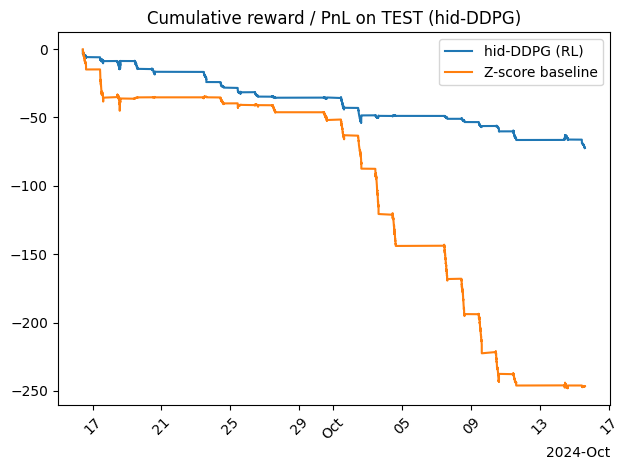

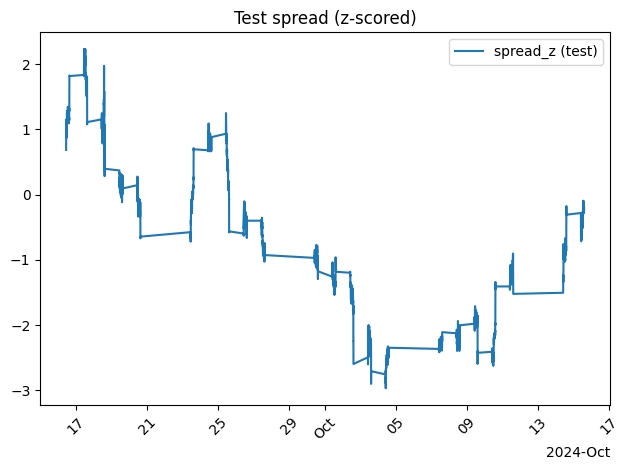

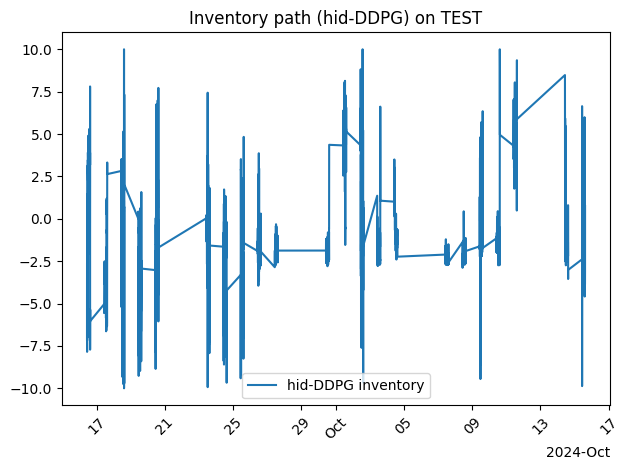

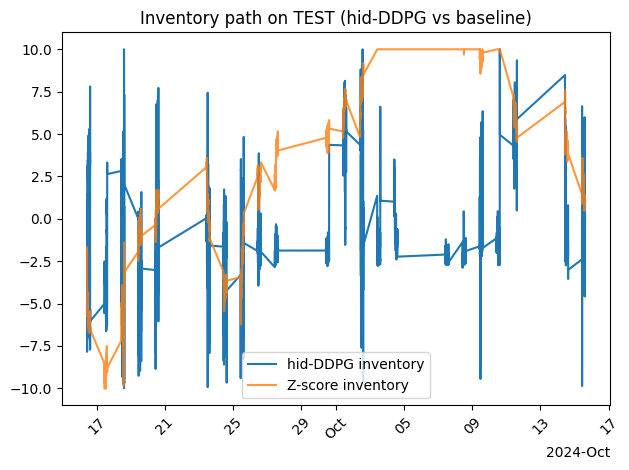

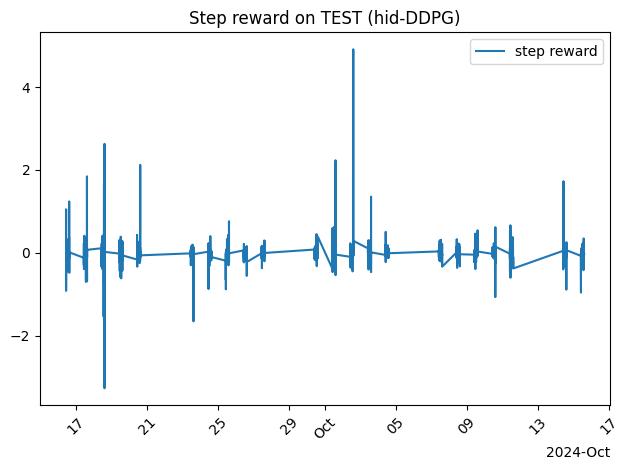

In [41]:
rewards = np.asarray(rewards, dtype=float)
inventories = np.asarray(inventories, dtype=float)
spreads = np.asarray(spreads, dtype=float)

cum_pnl_hid = np.cumsum(rewards)

t_hid = ts[:len(cum_pnl_hid)]

# --- 1) Cumulative reward / PnL on TEST ---
fig, ax = plt.subplots()

ax.plot(t_hid, cum_pnl_hid, label="hid-DDPG (RL)")
ax.plot(t_hid[:len(z_cum)], z_cum[:len(t_hid)], label="Z-score baseline")

ax.set_title("Cumulative reward / PnL on TEST (hid-DDPG)")
ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# --- 2) Spread (z-scored) ---
fig, ax = plt.subplots()

ax.plot(t_hid, spreads, label="spread_z (test)")
ax.set_title("Test spread (z-scored)")
ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# --- 3) Inventory path ---
fig, ax = plt.subplots()

ax.plot(t_hid, inventories, label="hid-DDPG inventory")
ax.set_title("Inventory path (hid-DDPG) on TEST")
ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# --- 4) Inventory comparison vs Z-score baseline ---
fig, ax = plt.subplots()

ax.plot(t_hid, inventories, label="hid-DDPG inventory")
ax.plot(t_hid[:len(z_I)], z_I[:len(t_hid)], label="Z-score inventory", alpha=0.8)

ax.set_title("Inventory path on TEST (hid-DDPG vs baseline)")
ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# --- 5) Optional: per-step reward ---
fig, ax = plt.subplots()

ax.plot(t_hid, rewards, label="step reward")
ax.set_title("Step reward on TEST (hid-DDPG)")
ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

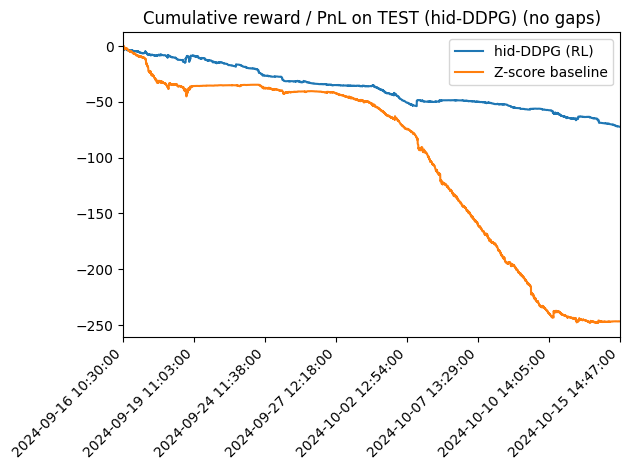

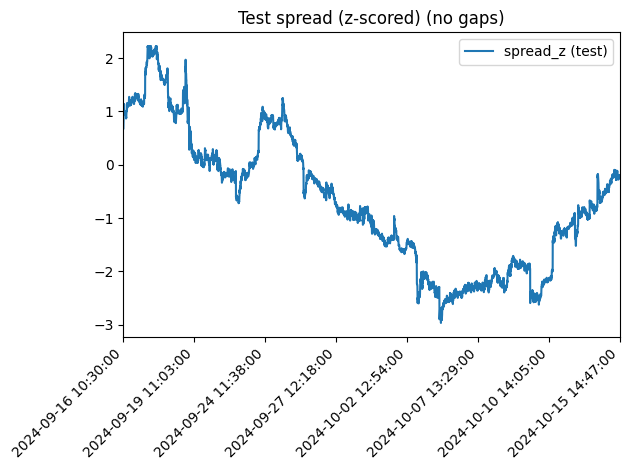

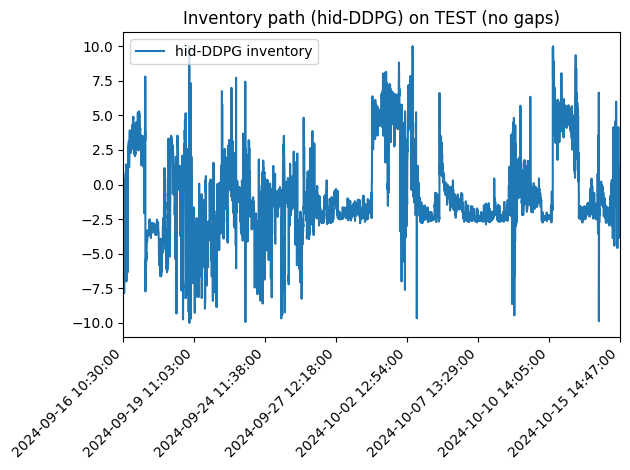

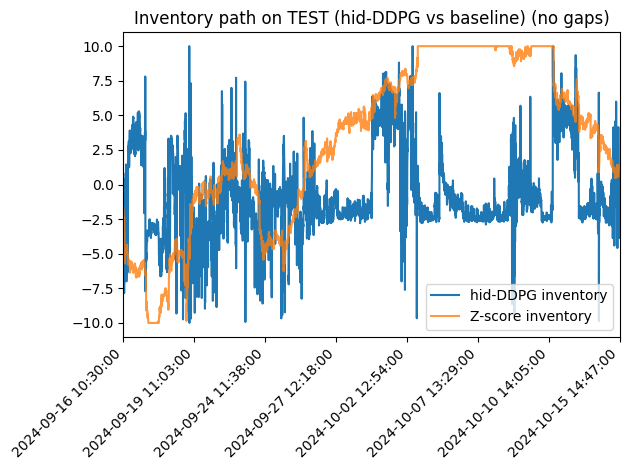

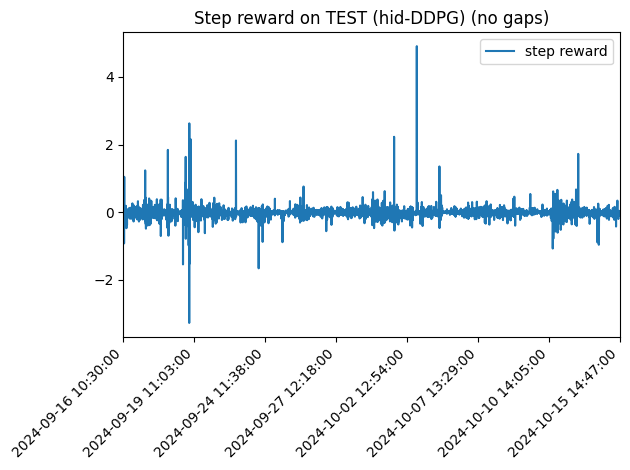

In [ ]:
import matplotlib.ticker as mticker

def no_gap_axis(ax, ts, max_labels=8):
    N = len(ts)
    x = np.arange(N)

    nlab = min(max_labels, N)
    tick_locs = np.linspace(0, N - 1, nlab, dtype=int)
    tick_labels = [str(ts[i]) for i in tick_locs]

    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")
    ax.set_xlim(0, N - 1)
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    return x

rewards = np.asarray(rewards, dtype=float)
inventories = np.asarray(inventories, dtype=float)
spreads = np.asarray(spreads, dtype=float)

cum_pnl_hid = np.cumsum(rewards)

N = min(len(ts), len(cum_pnl_hid), len(inventories), len(spreads))
ts_hid = ts[:N]

# --- 1) Cumulative reward / PnL on TEST ---
fig, ax = plt.subplots()
x = no_gap_axis(ax, ts_hid)

ax.plot(x, cum_pnl_hid[:N], label="hid-DDPG (RL)")

M = min(N, len(z_cum))
ax.plot(x[:M], np.asarray(z_cum, dtype=float)[:M], label="Z-score baseline")

ax.set_title("Cumulative reward / PnL on TEST (hid-DDPG)")
ax.legend()
plt.tight_layout()
plt.show()

# --- 2) Spread (z-scored) ---
fig, ax = plt.subplots()
x = no_gap_axis(ax, ts_hid)

ax.plot(x, spreads[:N], label="spread_z (test)")
ax.set_title("Test spread (z-scored)")
ax.legend()
plt.tight_layout()
plt.show()

# --- 3) Inventory path ---
fig, ax = plt.subplots()
x = no_gap_axis(ax, ts_hid)

ax.plot(x, inventories[:N], label="hid-DDPG inventory")
ax.set_title("Inventory path (hid-DDPG) on TEST")
ax.legend()
plt.tight_layout()
plt.show()

# --- 4) Inventory comparison vs Z-score baseline ---
fig, ax = plt.subplots()
x = no_gap_axis(ax, ts_hid)

ax.plot(x, inventories[:N], label="hid-DDPG inventory")

M = min(N, len(z_I))
ax.plot(x[:M], np.asarray(z_I, dtype=float)[:M], label="Z-score inventory", alpha=0.8)

ax.set_title("Inventory path on TEST (hid-DDPG vs baseline) (no gaps)")
ax.legend()
plt.tight_layout()
plt.show()

# --- 5) Per-step reward ---
fig, ax = plt.subplots()
x = no_gap_axis(ax, ts_hid)

ax.plot(x, rewards[:N], label="step reward")
ax.set_title("Step reward on TEST (hid-DDPG) (no gaps)")
ax.legend()
plt.tight_layout()
plt.show()

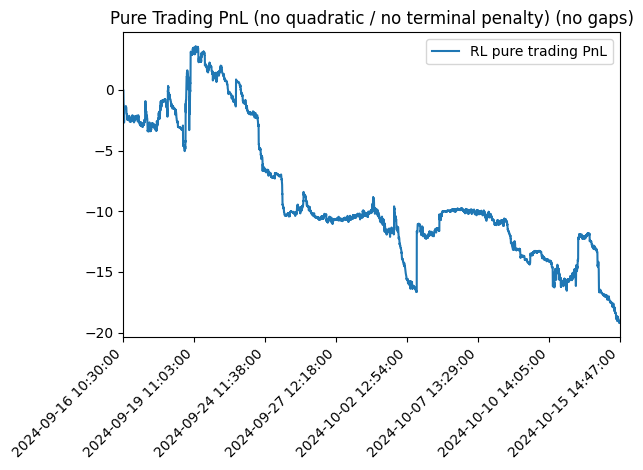

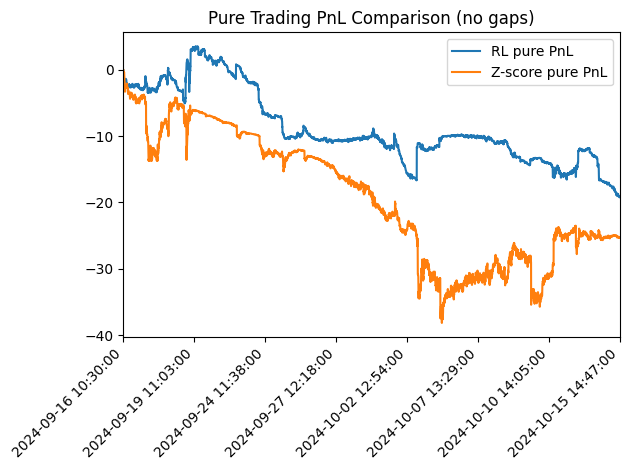

In [ ]:
def compute_pure_trading_pnl(spreads, inventories, trading_costs=0.05):
    spreads = np.asarray(spreads, dtype=float)
    inventories = np.asarray(inventories, dtype=float)

    dS = np.diff(np.concatenate(([spreads[0]], spreads)))

    pnl_step = []
    I_prev = 0.0

    for t in range(len(inventories)):
        I_curr = inventories[t]
        q = I_curr - I_prev

        pnl = I_curr * dS[t] - trading_costs * abs(q)
        pnl_step.append(pnl)

        I_prev = I_curr

    pnl_step = np.asarray(pnl_step, dtype=float)
    pnl_cum = np.cumsum(pnl_step)
    return pnl_cum, pnl_step

# ---------------- RL pure trading PnL ----------------
pnl_cum_pure, pnl_step_pure = compute_pure_trading_pnl(
    spreads=spreads,
    inventories=inventories,
    trading_costs=trading_costs,
)

N_rl = min(len(ts), len(pnl_cum_pure))
ts_rl = ts[:N_rl]

fig, ax = plt.subplots()
x = no_gap_axis(ax, ts_rl)

ax.plot(x, pnl_cum_pure[:N_rl], label="RL pure trading PnL")
ax.set_title("Pure Trading PnL (no quadratic / no terminal penalty) (no gaps)")
ax.legend()

plt.tight_layout()
plt.show()

# ---------------- Baseline (Z-score) pure trading PnL ----------------
N_z = min(len(z_I), len(z_test.values), len(ts))
z_spreads = np.asarray(z_test.values[:N_z], dtype=float)
z_invs = np.asarray(z_I[:N_z], dtype=float)

z_pnl_cum_pure, z_pnl_step_pure = compute_pure_trading_pnl(
    spreads=z_spreads,
    inventories=z_invs,
    trading_costs=trading_costs,
)

# ---------------- Comparison plot ----------------
N_cmp = min(len(pnl_cum_pure), len(z_pnl_cum_pure), len(ts))
ts_cmp = ts[:N_cmp]

fig, ax = plt.subplots()
x = no_gap_axis(ax, ts_cmp)

ax.plot(x, pnl_cum_pure[:N_cmp], label="RL pure PnL")
ax.plot(x, z_pnl_cum_pure[:N_cmp], label="Z-score pure PnL")

ax.set_title("Pure Trading PnL Comparison (no gaps)")
ax.legend()

plt.tight_layout()
plt.show()